Text(0, 0.5, 'Characteristic Strain')

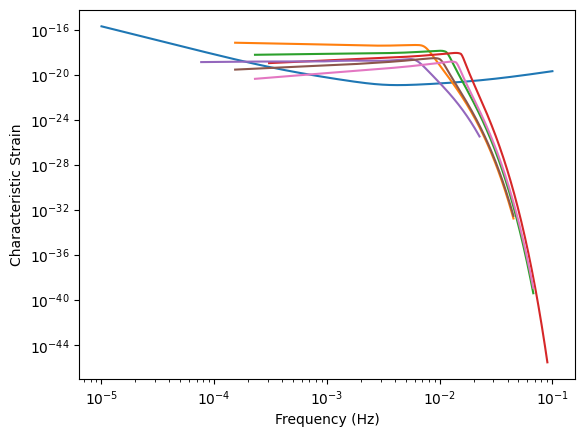

In [4]:
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity
from lisatools.utils.constants import *
import numpy as np
import matplotlib.pyplot as plt

wave_gen = PhenomHMAmpPhase()

m1 = 2e6
m2 = 7e5
chi1 = 0.5
chi2 = 0.7
dist = 15 * 1e9 * PC_SI
phi_ref = 0.6
f_ref = 0.0
t_ref = 1e6 # seconds
length = 1024

wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)

fn = np.logspace(-5, -1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="LISASens", return_type="char_strain") 


plt.loglog(fn, Sn_char_strain)
for i in range(6):
    char_strain = wave_gen.freqs_shaped[0, i] * wave_gen.amp[0, i]
    plt.loglog(wave_gen.freqs_shaped[0, i], char_strain)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic Strain")

In [23]:
from lisagwresponse import GalacticBinary
import numpy as np
from h5py import Dataset, File
orbits = "dist/orbit_data/keplerian-orbits-2-0.h5"

with File(orbits) as orbitf:
    t0 = orbitf.attrs["t0"]
print(t0)

galbin = GalacticBinary(
    A=1e-21,
    f=2e-3,
    df=1e-9,
    gw_beta=0,
    gw_lambda=0,
    orbits=orbits,
)

links = np.array([12, 21])
times = np.arange(t0 + 100, t0 + 150, 10)
response = galbin.compute_gw_response(times, links)

times = t0 + 10.0 + np.arange(100) * 1.0
response = galbin.compute_gw_response(times, links)
galbin.write(path="gws.h5")

You are using a GW file in a version that might not be fully supported


2019686400.0


Missing orbit information


ValueError: missing orbit information, use longer orbit file or adjust sampling

In [19]:
from lisagwresponse import GalacticBinary
import numpy as np
from h5py import Dataset, File
orbits = "dist/orbit_data/keplerian-orbits-2-0.h5"

with File(orbits,'r') as of:
    t_min = of.attrs['t0']
    dt_f  = of.attrs['dt']
    npts  = of.attrs['size']
t_max = t_min + (npts - 1)*dt_f

# pick a safe margin > max light-travel delay (say 20 s)
margin = 20.0  

times = np.linspace(
    t_min + margin,
    t_max - margin,
    100
)

links = np.array([12, 21])
response = galbin.compute_gw_response(times, links)

# now write, *using the same* t0, dt and size*
dt   = times[1] - times[0]
size = times.size
t0   = times[0]

# galbin.write(
#     path="gws.h5",
#     mode='w',
#     timeframe='both'
# )

response.write(
    "gws.h5",
    mode='w',         # overwrite existing file
    timeframe='both'  # or 'tcb' / 'tps' as desired
)

AttributeError: 'numpy.ndarray' object has no attribute 'write'

In [18]:
response.shape

(100, 2)

In [ ]:
with File(orbits,'r') as of:
    